<a href="https://colab.research.google.com/github/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/blob/main/Copy_of_Ademola_EKF_UKF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [172]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.integrate import odeint
import scipy.optimize

import sympy as sp

import pandas as pd

from scipy.integrate import odeint
import copy

In [173]:

try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

In [174]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

tb_simulations = import_local_or_github('simu', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
extended_kalman_filter = import_local_or_github('extended_kalman_filter', directory='../Utility')
unscented_kalman_filter = import_local_or_github('unscented_kalman_filter', directory='../Utility')

$$
\mathbf{\dot{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}) = \mathbf{f_0}(\mathbf{x}) + \mathbf{f_1}(\mathbf{x})\bbox[lightgreen]{\alpha} + \mathbf{f_2}(\mathbf{x})\bbox[lightgreen]{\kappa}
$$

$$
\frac{d}{dt}
\begin{bmatrix}
\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{V} \\[0.3em]
\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{R} \\[0.3em]
\bbox[pink]{\beta} \\[0.3em]
\bbox[pink]{\sigma}
\end{bmatrix} =
\overset{f_0}{\begin{bmatrix}
\bbox[lightblue]{\Lambda} - \bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[lightblue]{\mu}\bbox[yellow]{S} \\[0.3em]
0 - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\mu}\bbox[yellow]{V} \\[0.3em]
\bbox[pink]{\beta}\bbox[yellow]{SI} + \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{I} \\[0.3em]
\bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{R}\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} +
\overset{f_1}{\begin{bmatrix}
-\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{S} \\[0.3em]
0 \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\alpha} +
\overset{f_2}{\begin{bmatrix}
\bbox[pink]{\beta}\bbox[yellow]{SI} \\[0.3em]
\bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
-\bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\kappa}
$$

# Dynamics and measurement functions

In [175]:
# all three measurement functions can be accessed from the planar drone script:
h_a = tb_simulations.H('h_ivr').h
h_b = tb_simulations.H('h_all_svir').h
h_c = tb_simulations.H('h_comprehensive').h


In [176]:
f = tb_simulations.F().f
h = h_b # choose one of the measurement functions

In [177]:
h(None, None, return_measurement_names=True)

['S_absolute', 'V_absolute', 'I_absolute', 'R_absolute']

In [178]:
def u_func(x_vec, t):
    """Simple vaccination and social distancing controller"""
    I = x_vec[2]

    # Vaccination rate: increase when infections are high
    I_threshold = 0.005  # 0.5% of population
    if I > I_threshold:
        alpha = 0.01  # 1% vaccination rate when infections high
    else:
        alpha = 0.005  # 0.5% baseline vaccination

    # Social distancing: activate when infections high
    if I > I_threshold:
        kappa = 0.3  # 30% reduction in contacts
    else:
        kappa = 0.1  # 10% baseline

    return np.array([alpha, kappa])

In [179]:
def f_ode(x_vec, t):
    """Wrapper for odeint"""
    u_vec = u_func(x_vec, t)
    return f(x_vec, u_vec)


In [180]:
N = 223000000
x0 = np.array([
    52309000/N,      # S: 0.2345 (23.45%)
    158330000/N,     # V: 0.7100 (71.00%)
    361000/N,        # I: 0.0016 (0.16%)
    12000000/N,      # R: 0.0538 (5.38%)
    0.00003,         # beta: realistic TB transmission (slow)
    0.85             # sigma: 85% vaccine efficacy
])

# Run simulation

In [181]:
t_sim = np.arange(0, 365, 1.0)
result = odeint(f_ode, x0, t_sim)


In [182]:
x_sim = {
    'S': result[:, 0],
    'V': result[:, 1],
    'I': result[:, 2],
    'R': result[:, 3],
    'beta': result[:, 4],
    'sigma': result[:, 5]
}

In [183]:
u_sim = {'alpha': [], 'kappa': []}
for i in range(len(t_sim)):
    u = u_func(result[i], t_sim[i])
    u_sim['alpha'].append(u[0])
    u_sim['kappa'].append(u[1])

In [184]:
y_sim_absolute = {
    'S_absolute': x_sim['S'] * N,
    'V_absolute': x_sim['V'] * N,
    'I_absolute': x_sim['I'] * N,
    'R_absolute': x_sim['R'] * N
}

# Simulate noisy measurements

In [185]:
measurement_noise_stds = {
    'S_absolute': 100000.0,   # ±100K
    'I_absolute': 10000.0,    # ±10K
    'V_absolute': 100000.0,   # ±100K
    'R_absolute': 5000.0
}

In [186]:
# Add noise
np.random.seed(42)
y_noisy_absolute = {
    key: y_sim_absolute[key] + np.random.normal(0, measurement_noise_stds[key], len(t_sim))
    for key in y_sim_absolute.keys()
}

In [187]:
y_noisy = {key: y_noisy_absolute[key] / N for key in y_noisy_absolute.keys()}

<Axes: xlabel='Time', ylabel='R_absolute'>

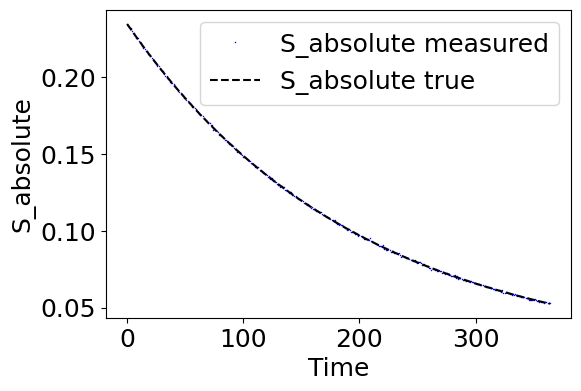

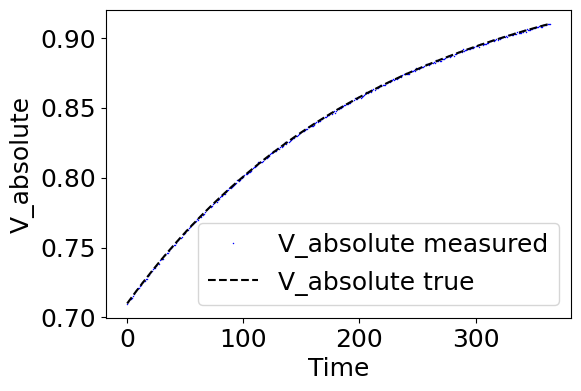

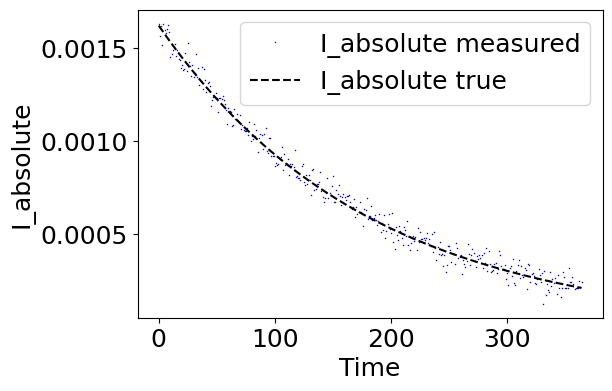

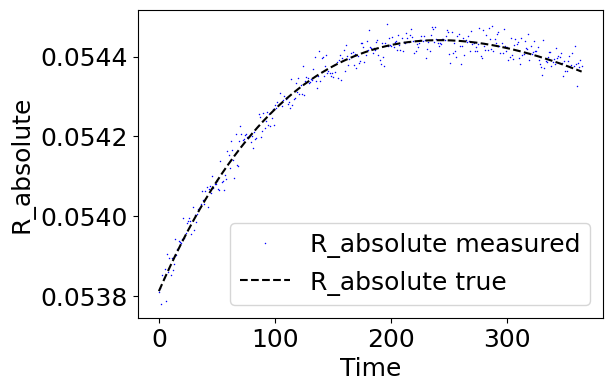

In [188]:

plot_tme(t_sim, x_sim['S'], y_noisy['S_absolute'], label_var='S_absolute')
plot_tme(t_sim, x_sim['V'], y_noisy['V_absolute'], label_var='V_absolute')
plot_tme(t_sim, x_sim['I'], y_noisy['I_absolute'], label_var='I_absolute')
plot_tme(t_sim, x_sim['R'], y_noisy['R_absolute'], label_var='R_absolute')

### Save data as dataframes

In [189]:
y_noisy_df = pd.DataFrame(y_noisy)
u_sim_df = pd.DataFrame(u_sim)

# Kalman filter parameters and initilization

In [190]:
x0_ekf = np.array([x_sim['S'][0], x_sim['V'][0], x_sim['I'][0],
                   x_sim['R'][0], x_sim['beta'][0], x_sim['sigma'][0]])
u0 = np.array([u_sim['alpha'][0], u_sim['kappa'][0]])

In [191]:
P0 = np.diag([0.01, 0.01, 0.001, 0.01, 0.00001, 0.01])
Q = np.diag([1e-6, 1e-6, 1e-7, 1e-6, 1e-10, 1e-10])
R_stds = np.array([100000/N, 100000/N, 10000/N, 50000/N])
R = np.diag(R_stds**2)

# Extended Kalman Filter

In [192]:
EKF = extended_kalman_filter.EKF(
    f, h, x0_ekf, u0, P0, Q, R,
    dynamics_type='continuous',
    discretization_timestep=1.0,
    circular_measurements=(0, 0, 0, 0, 0, 0)
)

In [193]:
EKF.estimate(y_noisy_df, u_sim_df)

In [194]:
EKF.history.keys()

dict_keys(['X', 'U', 'Z', 'P', 'P_diags', 'R', 'Q', 'F', 'H', 'S', 'K', 'E', 'rho', 'Jk', 'inv_Jk'])

In [195]:
# State estimate
x_est = pd.DataFrame(np.vstack(EKF.history['X']), columns=f(None,None,return_state_names=True))

In [196]:
# Covariance diagonals
P_diags = np.vstack([np.diag(EKF.history['P'][i]) for i in range(len(EKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=f(None,None,return_state_names=True))

## Plots

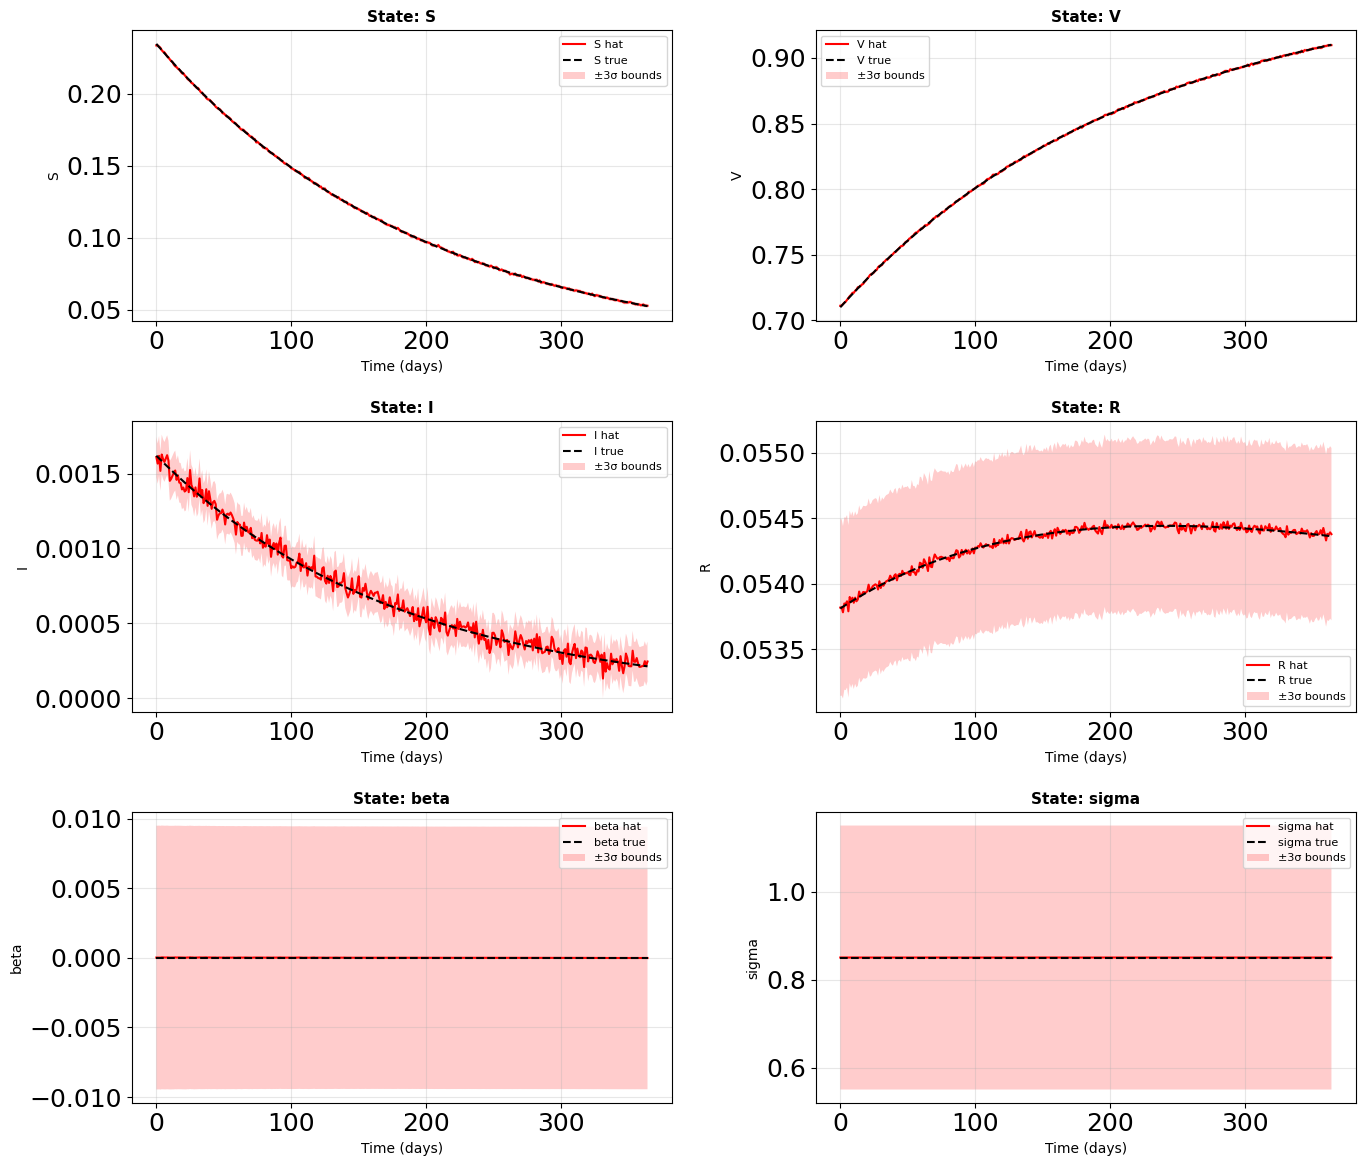

In [197]:
import matplotlib.pyplot as plt
import numpy as np

# Get state names
state_names = f(None, None, return_state_names=True)
n_states = len(state_names)

# Create subplots - 3 rows x 2 columns for 6 states
fig, axes = plt.subplots(3, 2, figsize=(14, 12), dpi=100)
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Convert to numpy arrays once
x_est_array = np.array(x_est)
P_diags_array = np.array(P_diags)

# Plot each state
for i, state in enumerate(state_names):
    ax = axes[i]

    # Extract columns for this state
    x_est_col = x_est_array[:, i]
    P_diag_col = P_diags_array[:, i]

    # Plot true trajectory, measurements (if available), and estimate
    if state in y_noisy.keys():
        # If we have measurements for this state
        plot_tme(t_sim, x_sim[state], y_noisy[state], x_est_col,
                label_var=state, ax=ax)
    else:
        # No measurements for this state (e.g., beta, sigma)
        plot_tme(t_sim, x_sim[state], None, x_est_col,
                label_var=state, ax=ax)

    # Add 3-sigma uncertainty bounds
    plus_3sigma = x_est_col + 3*np.sqrt(P_diag_col)
    minus_3sigma = x_est_col - 3*np.sqrt(P_diag_col)
    ax.fill_between(t_sim, plus_3sigma, minus_3sigma,
                    facecolor='red', edgecolor='none', alpha=0.2,
                    label='±3σ bounds')

    # Formatting
    ax.set_xlabel('Time (days)', fontsize=10)
    ax.set_ylabel(f'{state}', fontsize=10)
    ax.set_title(f'State: {state}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# Unscented Kalman Filter

In [203]:
UKF = unscented_kalman_filter.UKF(f, h, x0, u0, P0, Q, R,
                                 dynamics_type='continuous', discretization_timestep=1.0,
                                 alpha=0.1)

In [204]:
UKF.estimate(y_noisy_df, u_sim_df)

In [205]:
UKF.history.keys()

dict_keys(['X', 'P', 'P_diags', 'sigma_points'])

In [206]:
# State estimate
x_est = pd.DataFrame(np.vstack(UKF.history['X']), columns=f(None,None,return_state_names=True))

In [207]:
# Covariance diagonals
P_diags = np.vstack([np.diag(UKF.history['P'][i]) for i in range(len(UKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=f(None,None,return_state_names=True))

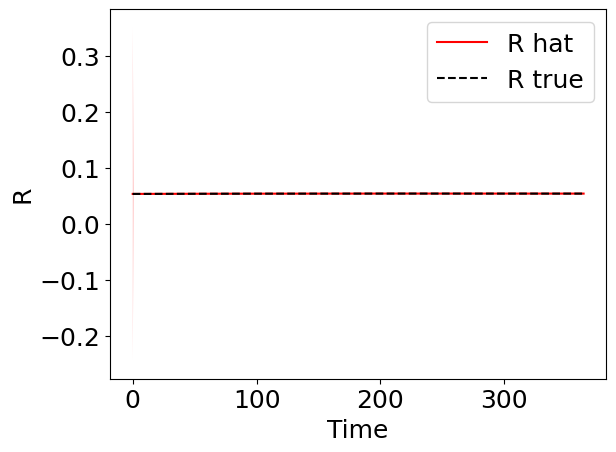

In [209]:
fig = plt.figure()
ax = fig.add_subplot(111)

state = 'R'

plot_tme(t_sim, x_sim[state], None, x_est[state], label_var=state, ax=ax)

plus3sigma = x_est[state] + 3*np.sqrt(P_diags[state])
minus3sigma = x_est[state] - 3*np.sqrt(P_diags[state])

ax.fill_between(t_sim, plus3sigma, minus3sigma, facecolor='red', edgecolor='none', alpha=0.2)